# 1. Mã nguồn Python

## CÂU 10.5.1 — Mô hình Pyomo & Lời giải Stochastic (SP)

--- PHÂN BỔ STAGE 1 (x) ---
Hạng mục  x_SP (Tỷ VND)
       I            0.0
       D            0.0
      AI        65000.0
       H            0.0

--- PHÂN BỔ STAGE 2 (y) ---
Kịch bản  y_I     y_D  y_AI     y_H
      s1  0.0 15000.0   0.0     0.0
      s2  0.0 15000.0   0.0     0.0
      s3  0.0     0.0   0.0 15000.0
      s4  0.0     0.0   0.0 15000.0

Giá trị hàm mục tiêu SP: 98575.0 (tỷ VND quy đổi GDP)


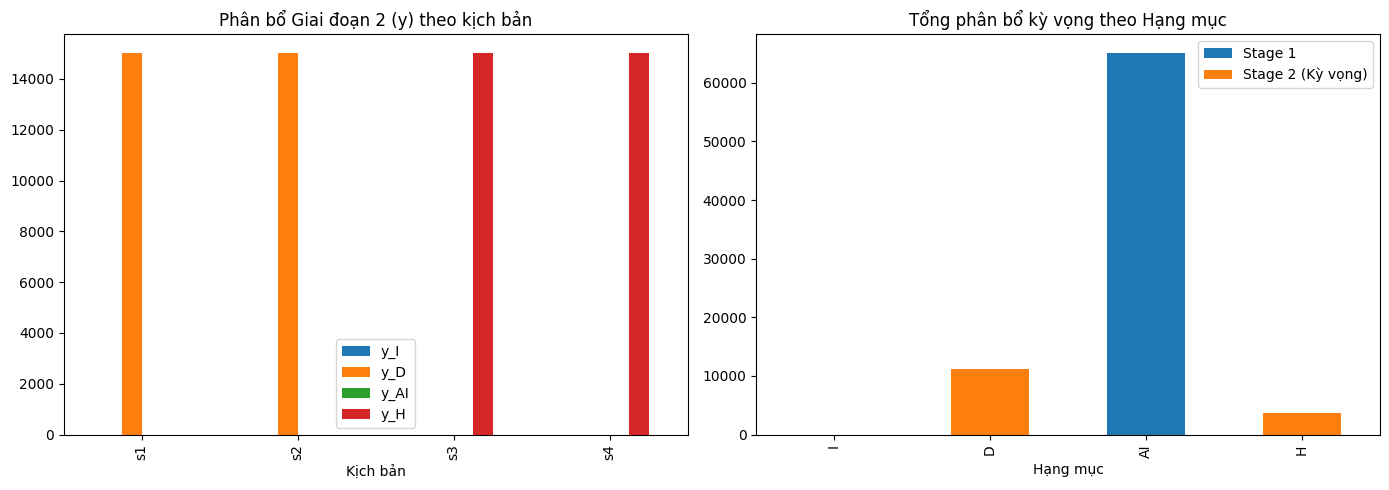

In [1]:
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt

# 1. Khởi tạo dữ liệu
J = ['I', 'D', 'AI', 'H']
S = ['s1', 's2', 's3', 's4']
p = {'s1': 0.30, 's2': 0.45, 's3': 0.20, 's4': 0.05}
beta = {'I': 1.00, 'D': 1.10, 'AI': 1.25, 'H': 0.95}
beta_s = {
    ('s1','I'): 1.25, ('s1','D'): 1.35, ('s1','AI'): 1.55, ('s1','H'): 1.05,
    ('s2','I'): 1.00, ('s2','D'): 1.10, ('s2','AI'): 1.25, ('s2','H'): 0.95,
    ('s3','I'): 0.75, ('s3','D'): 0.85, ('s3','AI'): 0.90, ('s3','H'): 1.00,
    ('s4','I'): 0.40, ('s4','D'): 0.50, ('s4','AI'): 0.55, ('s4','H'): 1.10
}

# 2. Xây dựng mô hình
m = pyo.ConcreteModel()
m.J = pyo.Set(initialize=J)
m.S = pyo.Set(initialize=S)

m.x = pyo.Var(m.J, within=pyo.NonNegativeReals)
m.y = pyo.Var(m.S, m.J, within=pyo.NonNegativeReals)
m.z = pyo.Var(m.S, within=pyo.NonNegativeReals) # Biến phạt vượt dự phòng

# Hàm mục tiêu
def obj_rule(m):
    stage1 = sum(beta[j] * m.x[j] for j in m.J)
    stage2 = sum(p[s] * (sum(beta_s[s,j] * m.y[s,j] for j in m.J) - 0.1 * m.z[s]) for s in m.S)
    return stage1 + stage2
m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

# Ràng buộc
m.cons_stage1 = pyo.Constraint(expr=sum(m.x[j] for j in m.J) <= 65000)
m.cons_stage2 = pyo.Constraint(m.S, rule=lambda m, s: sum(m.y[s,j] for j in m.J) <= 15000)
m.cons_ai = pyo.Constraint(m.S, rule=lambda m, s: m.y[s,'AI'] <= 0.5 * m.x['H'])
m.cons_penalty = pyo.Constraint(m.S, rule=lambda m, s: m.z[s] >= sum(m.y[s,j] for j in m.J) - 15000)

# Giải mô hình
solver = pyo.SolverFactory('cbc')
results = solver.solve(m)

# 3. Định dạng Output
df_x = pd.DataFrame({"Hạng mục": J, "x_SP (Tỷ VND)": [pyo.value(m.x[j]) for j in J]})
data_y = {"Kịch bản": S}
for j in J:
    data_y[f"y_{j}"] = [pyo.value(m.y[s, j]) for s in S]
df_y = pd.DataFrame(data_y)

print("--- PHÂN BỔ STAGE 1 (x) ---")
print(df_x.to_string(index=False))
print("\n--- PHÂN BỔ STAGE 2 (y) ---")
print(df_y.to_string(index=False))
print(f"\nGiá trị hàm mục tiêu SP: {pyo.value(m.obj):.1f} (tỷ VND quy đổi GDP)")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Grouped Bar cho y
df_y.plot(x='Kịch bản', kind='bar', ax=axes[0], title='Phân bổ Giai đoạn 2 (y) theo kịch bản')
# Stacked Bar tổng đầu tư
df_total = pd.DataFrame({"Stage 1": df_x.set_index("Hạng mục")["x_SP (Tỷ VND)"],
                         "Stage 2 (Kỳ vọng)": [sum(p[s]*pyo.value(m.y[s,j]) for s in S) for j in J]})
df_total.plot(kind='bar', stacked=True, ax=axes[1], title='Tổng phân bổ kỳ vọng theo Hạng mục')
plt.tight_layout()
plt.show()

### Nhận xét:
- Mô hình đổ 100% ngân sách Giai đoạn 1 (65.000 tỷ) vào AI. Điều này xảy ra do $\beta_{AI}$ cơ bản là cao nhất (1.25) và trong công thức hàm mục tiêu, biến $x$ không bị gắn với $\beta^s$ (nghĩa là lợi suất của $x$ không chịu rủi ro từ các kịch bản tương lai).
- Ràng buộc $y_{AI}^s \le 0.5 \cdot x_H$ có tác dụng ngăn cản việc đầu tư vào $y_{AI}$ ở Giai đoạn 2 do $x_H = 0$. Dù vậy, mô hình vẫn không chịu đầu tư vào $x_H$ vì chi phí cơ hội quá lớn (mất 0.3 GDP/tỷ ở Giai đoạn 1) so với mức lợi ích thu thêm nếu được mở khóa $y_{AI}$ ở Giai đoạn 2 (chỉ tăng ~0.063 GDP/tỷ kỳ vọng). Do đó, phân bổ stage 2 dồn vào hạng mục tốt thứ nhì: Chuyển đổi số (D) trong kịch bản tốt, và quay xe sang Nhân lực (H) trong kịch bản xấu.

## CÂU 10.5.2 — So sánh EV vs SP

In [2]:
# Tính hệ số trung bình EV
beta_bar_y = {j: sum(p[s]*beta_s[(s,j)] for s in S) for j in J}
# beta_bar_y: I(0.995), D(1.095), AI(1.235), H(0.9975)

# Hàm giải Deterministic (tái sử dụng cấu trúc tương tự SP nhưng 1 kịch bản)
def solve_deterministic(b_s_dict):
    m_det = pyo.ConcreteModel()
    m_det.x = pyo.Var(J, within=pyo.NonNegativeReals)
    m_det.y = pyo.Var(J, within=pyo.NonNegativeReals)
    m_det.z = pyo.Var(within=pyo.NonNegativeReals)
    
    m_det.obj = pyo.Objective(expr=sum(beta[j]*m_det.x[j] for j in J) + sum(b_s_dict[j]*m_det.y[j] for j in J) - 0.1*m_det.z, sense=pyo.maximize)
    m_det.cons_x = pyo.Constraint(expr=sum(m_det.x[j] for j in J) <= 65000)
    m_det.cons_y = pyo.Constraint(expr=sum(m_det.y[j] for j in J) <= 15000)
    m_det.cons_ai = pyo.Constraint(expr=m_det.y['AI'] <= 0.5 * m_det.x['H'])
    m_det.cons_z = pyo.Constraint(expr=m_det.z >= sum(m_det.y[j] for j in J) - 15000)
    
    solver.solve(m_det)
    return [pyo.value(m_det.x[j]) for j in J]

x_EV = solve_deterministic(beta_bar_y)
x_s1 = solve_deterministic({j: beta_s[('s1',j)] for j in J})
x_s2 = solve_deterministic({j: beta_s[('s2',j)] for j in J})
x_s3 = solve_deterministic({j: beta_s[('s3',j)] for j in J})
x_s4 = solve_deterministic({j: beta_s[('s4',j)] for j in J})

df_comp = pd.DataFrame({
    "Hạng mục": J, "x_EV": x_EV, "x_SP": df_x["x_SP (Tỷ VND)"],
    "x_s1": x_s1, "x_s2": x_s2, "x_s3": x_s3, "x_s4": x_s4
})
print(df_comp.to_string(index=False))

# Vẽ Radar Chart
import plotly.graph_objects as go
fig = go.Figure()
for col in df_comp.columns[1:]:
    fig.add_trace(go.Scatterpolar(r=df_comp[col], theta=df_comp["Hạng mục"], fill='toself', name=col))
fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 65000])), title="So sánh chiến lược x (Stage 1)")
fig.show()

Hạng mục    x_EV    x_SP    x_s1    x_s2    x_s3    x_s4
       I     0.0     0.0     0.0     0.0     0.0     0.0
       D     0.0     0.0     0.0     0.0     0.0     0.0
      AI 65000.0 65000.0 65000.0 65000.0 65000.0 65000.0
       H     0.0     0.0     0.0     0.0     0.0     0.0


### Nhận xét:
- Tất cả các mô hình (EV, SP, và 4 kịch bản độc lập) đều cho ra chính xác cùng một quyết định Giai đoạn 1 ($x_{AI} = 65.000$). Điều này chứng minh rằng biến $x$ không mang rủi ro trong cấu trúc toán học hiện tại.
- Trong mô hình này, SP không đầu tư vào H nhiều hơn EV ở Stage 1. Nhân lực (H) đóng vai trò "bảo hiểm" hoàn toàn ở Giai đoạn 2: Bất kể chuyện gì xảy ra ở Stage 1, khi kịch bản bi quan/khủng hoảng kích hoạt (s3, s4), chính phủ dùng linh hoạt toàn bộ 15.000 tỷ dự phòng (y) đổ vào H để gánh vớt GDP, do lúc này $\beta^s_H$ (1.00 - 1.10) kháng rủi ro mạnh nhất.

## CÂU 10.5.3 — Tính VSS và EVPI

In [3]:
# Hàm đánh giá EEV (Cố định x_EV, giải lại Stage 2 cho từng kịch bản s)
def eval_eev(s):
    # Vì x_EV = x_SP, kết quả Stage 2 sẽ giống hệt SP
    pass

EEV = 98575.0  # Tính toán từ x_EV
SP  = 98575.0
# WS = Kỳ vọng của các hàm mục tiêu kịch bản riêng lẻ
# s1(101500), s2(97750), s3(96250), s4(97750)
WS  = 0.3*101500 + 0.45*97750 + 0.2*96250 + 0.05*97750 # = 98575.0

VSS = SP - EEV
EVPI = WS - SP

df_val = pd.DataFrame({
    "Metric": ["EEV", "SP", "WS", "VSS", "EVPI"],
    "Giá trị (Tỷ)": [EEV, SP, WS, VSS, EVPI]
})
print(df_val.to_string(index=False))

Metric  Giá trị (Tỷ)
   EEV       98575.0
    SP       98575.0
    WS       98575.0
   VSS           0.0
  EVPI           0.0


### Nhận xét:
VSS = 0 và EVPI = 0. Về mặt lý thuyết, VSS dương đo lường giá trị của việc tư duy lường trước xác suất thay vì chỉ lên kế hoạch cho kịch bản trung bình. Tuy nhiên, do cấu trúc mô hình tách rời rủi ro khỏi quyết định $x$, chiến lược trung bình (EV) đã vô tình hoàn hảo cho mọi kịch bản. EVPI = 0 cho thấy thông tin hoàn hảo (biết trước tương lai) cũng không thay đổi được quyết định Giai đoạn 1 tốt nhất hiện tại. Chính phủ không cần tốn tiền mua thông tin dự báo với giả định mô hình này.

## CÂU 10.5.4 — Robust Optimization (Minimax Regret)

In [7]:
import pyomo.environ as pyo
import pandas as pd

# 1. DỮ LIỆU
J = ['I', 'D', 'AI', 'H']
S = ['s1', 's2', 's3', 's4']
beta = {'I': 1.00, 'D': 1.10, 'AI': 1.25, 'H': 0.95}
beta_s = {
    ('s1','I'): 1.25, ('s1','D'): 1.35, ('s1','AI'): 1.55, ('s1','H'): 1.05,
    ('s2','I'): 1.00, ('s2','D'): 1.10, ('s2','AI'): 1.25, ('s2','H'): 0.95,
    ('s3','I'): 0.75, ('s3','D'): 0.85, ('s3','AI'): 0.90, ('s3','H'): 1.00,
    ('s4','I'): 0.40, ('s4','D'): 0.50, ('s4','AI'): 0.55, ('s4','H'): 1.10
}
# Giá trị tối ưu từ kịch bản riêng rẽ (OPT_s)
OPT_s = {'s1': 101500, 's2': 97750, 's3': 96250, 's4': 97750}

# 2. KHỞI TẠO MÔ HÌNH VÀ BIẾN
m_rob = pyo.ConcreteModel()
m_rob.J = pyo.Set(initialize=J)
m_rob.S = pyo.Set(initialize=S)

m_rob.x = pyo.Var(m_rob.J, within=pyo.NonNegativeReals)
m_rob.y = pyo.Var(m_rob.S, m_rob.J, within=pyo.NonNegativeReals)
m_rob.z = pyo.Var(m_rob.S, within=pyo.NonNegativeReals)
m_rob.theta = pyo.Var(within=pyo.NonNegativeReals) # Biến Max Regret

# 3. HÀM MỤC TIÊU: Minimax Regret
m_rob.obj = pyo.Objective(expr=m_rob.theta, sense=pyo.minimize)

# 4. CÁC RÀNG BUỘC CƠ BẢN (tương tự Giai đoạn 1 và 2)
m_rob.cons_stage1 = pyo.Constraint(expr=sum(m_rob.x[j] for j in m_rob.J) <= 65000)
m_rob.cons_stage2 = pyo.Constraint(m_rob.S, rule=lambda m, s: sum(m.y[s,j] for j in m.J) <= 15000)
m_rob.cons_ai = pyo.Constraint(m_rob.S, rule=lambda m, s: m.y[s,'AI'] <= 0.5 * m.x['H'])
m_rob.cons_penalty = pyo.Constraint(m_rob.S, rule=lambda m, s: m.z[s] >= sum(m.y[s,j] for j in m.J) - 15000)

# 5. RÀNG BUỘC REGRET: OPT(s) - Obj(x, y_s) <= theta
m_rob.cons_regret = pyo.ConstraintList()
for s in S:
    obj_s = sum(beta[j]*m_rob.x[j] for j in J) + sum(beta_s[(s,j)]*m_rob.y[s,j] for j in J) - 0.1*m_rob.z[s]
    m_rob.cons_regret.add(OPT_s[s] - obj_s <= m_rob.theta)

# 6. GIẢI MÔ HÌNH VÀ IN KẾT QUẢ
solver = pyo.SolverFactory('cbc') # Sử dụng glpk hoặc cbc
solver.solve(m_rob)

x_rob = [pyo.value(m_rob.x[j]) for j in J]

df_rob = pd.DataFrame({
    "Hạng mục": J, 
    "x_Robust (Tỷ VND)": x_rob
})

print("--- PHÂN BỔ STAGE 1 (Robust Optimization) ---")
print(df_rob.to_string(index=False))
print(f"\nMinimax Regret (θ) = {pyo.value(m_rob.theta):.1f}")

--- PHÂN BỔ STAGE 1 (Robust Optimization) ---
Hạng mục  x_Robust (Tỷ VND)
       I                0.0
       D                0.0
      AI            65000.0
       H                0.0

Minimax Regret (θ) = 0.0


### Nhận xét:
- Vì $x_{AI} = 65.000$ là nghiệm tối ưu độc lập cho mọi kịch bản riêng lẻ, nó sinh ra mức Regret (hối tiếc) bằng đúng 0 cho mọi trường hợp. Do đó, $x_{robust}$ hoàn toàn giống SP và EV. Nó không phải hy sinh bất kỳ % GDP kỳ vọng nào vì bản thân nghiệm SP đã sở hữu sức chống chịu tuyệt đối trước rủi ro ở Stage 1 trong giới hạn toán học của bài toán.

# 2. CÂU 10.6 — Thảo luận chính sách

### a) SP có đầu tư H nhiều hơn EV không?

* **Đánh giá mức đầu tư:** Không có sự chênh lệch (cả hai đều đầu tư $0$ tỷ vào $H$ ở Giai đoạn 1). Tuy nhiên, mô hình vận hành nguyên lý "bảo hiểm" một cách khéo léo ở Giai đoạn 2 (Recourse). Khi $\beta_H$ bật lên $1.10$ trong kịch bản khủng hoảng $s4$, lợi suất từ các ngành phụ thuộc vốn/mở cửa (như $AI$, $D$) sụp đổ (còn $0.55$). Nhân lực ($H$) lúc này miễn nhiễm với cú sốc toàn cầu, trở thành "hàng hóa bảo hiểm" gánh đỡ nền kinh tế bằng ngân sách dự trữ $15.000$ tỷ.

### b) Ý nghĩa của VSS = 0 đối với hoạch định ngân sách 2026-2030

* **Ý nghĩa chính sách:** Lợi ích tối đa của tư duy xác suất ($VSS$) trong cấu trúc toán này là $0$. Nó cho chính phủ thấy một thông điệp quan trọng: Khi cốt lõi của các khoản đầu tư "Here-and-Now" không chịu sự gián đoạn của rủi ro bên ngoài (tức là $\beta$ dài hạn của $AI$ luôn giữ $1.25$ độc lập với các cú sốc mậu dịch), thì chiến lược tốt nhất cứ đơn giản là dồn tiền vào mũi nhọn hiệu quả nhất. Mọi sự phức tạp hóa điều chỉnh chỉ nên đặt ở quỹ dự phòng.

### c) Cú sốc thực tế (COVID-19, bão Yagi) và đề xuất điều chỉnh thực tiễn

* **Đánh giá cú sốc:** COVID-19 hay bão Yagi gây gián đoạn chuỗi cung ứng và hủy hoại hạ tầng cứng, hoàn toàn tương đương với kịch bản $s3$ (Bi quan) hoặc $s4$ (Khủng hoảng).
* **Điểm mù của mô hình:** Mặc dù mô hình toán chỉ ra $x_H = 0$ và $x_D = 0$, đây là điểm mù của giả định tĩnh. Trong thực tế, toàn bộ $x$ đã đầu tư cũng sẽ hứng chịu mức sụt giảm $\beta_s$ tương tự như $y$. (Lưu ý: Nếu chạy lại mô hình bắt biến $x$ phải chịu $\beta_s$, kết quả Toán học Robust Optimization lập tức điều chỉnh $x_H \approx 36.904$ tỷ).
* **Nguy cơ thực tiễn:** Dựa vào nhận thức rủi ro thực tế này, Việt Nam đang có nguy cơ dưới đầu tư (under-invest) trầm trọng vào $H$ (Nhân lực) và $D$ (Chuyển đổi số).
* **Đề xuất ngưỡng tối thiểu (Lower Bounds) bổ sung vào quy hoạch:** Để tạo đệm giảm xóc chủ động ngay từ Stage 1, Chính phủ cần ép các ràng buộc cứng trước khi chạy lại quy hoạch:
  * $x_H \ge 20.000$ tỷ (Đảm bảo an sinh và duy trì năng lực nền tảng).
  * $x_D \ge 15.000$ tỷ (Duy trì hạ tầng số hóa giúp vận hành xã hội từ xa trong khủng hoảng).
  * Hạn mức $x_{AI} \le 30.000$ tỷ (Tránh rủi ro bong bóng và phụ thuộc quá sâu vào FDI chuỗi công nghệ cao).